In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.5/974.5 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [13]:
import os
import cv2
import random
from ultralytics import YOLO
from tqdm import tqdm
import shutil
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from ultralytics import YOLO


image 1/1 /content/drive/MyDrive/datasets/test/fla3.jpg: 640x480 1 cat, 309.7ms
Speed: 5.6ms preprocess, 309.7ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 480)


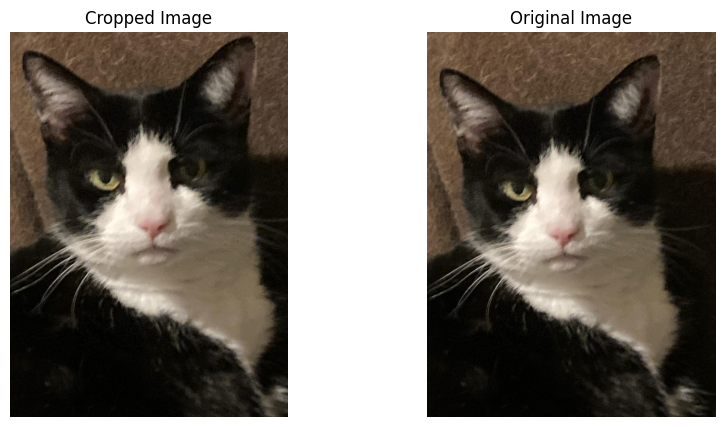

Cat in the Picture!


In [16]:
model = YOLO("yolov8n.pt")
img_path = "/content/drive/MyDrive/datasets/test/fla3.jpg"
img = cv2.imread(img_path)
img_array = np.array(img)
IMG_SIZE = (180, 180)
results = model.predict(source=img_path, conf=0.47, classes=[15])

if results[0].boxes:
  cat = 1
  boxes = results[0].boxes.xyxy.tolist()
  for box in boxes:
      x_min, y_min, x_max, y_max = map(int, box)

      cropped_img_array = img_array[y_min:y_max, x_min:x_max]
      if isinstance(cropped_img_array, tf.Tensor):
          cropped_img_array = cropped_img_array.numpy()

      cropped_img_array_rgb = cv2.cvtColor(cropped_img_array, cv2.COLOR_BGR2RGB)
      cropped_img = Image.fromarray(cropped_img_array_rgb.astype('uint8'))
      img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

      plt.figure(figsize=(10, 5))
      plt.subplot(1, 2, 1)
      plt.imshow(cropped_img)
      plt.axis("off")
      plt.title("Cropped Image")
      plt.subplot(1, 2, 2)
      plt.imshow(img_rgb)
      plt.axis("off")
      plt.title("Original Image")
      plt.show()
      print("Cat in the Picture!")
      cropped_img_resized = cropped_img.resize(IMG_SIZE)
      img_array_resized = keras.utils.img_to_array(cropped_img_resized)
      img_array_resized = img_array_resized / 255.0
      img_array_resized = tf.expand_dims(img_array_resized, axis=0)
else:
  cat = 0
  print("No cat in the picture!")

In [18]:
keras_model_bruno = tf.keras.models.load_model("/content/drive/MyDrive/repos/keras-distinguish-own-cat-from-others-model/models/model4_bruno.keras")
keras_model_flaekli = tf.keras.models.load_model("/content/drive/MyDrive/repos/keras-distinguish-own-cat-from-others-model/models/model1_flaekli.keras")
predictions_bruno = keras_model_bruno.predict(img_array_resized)
score_bruno = float(predictions_bruno[0])
predictions_flaekli = keras_model_flaekli.predict(img_array_resized)
score_flaekli = float(predictions_flaekli[0])

if 100 * (1 - score_bruno) > 25:
  print(f"Bruno is in the picture! ({100 * (1 - score_bruno):.2f}%)")


if 100 * (1 - score_flaekli) > 25:
  print(f"Flaekli is in the picture! ({100 * (1 - score_flaekli):.2f}%)")




1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


<ipython-input-18-e0e22f63995b>:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_bruno = float(predictions_bruno[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Flaekli is in the picture! (96.83%)


<ipython-input-18-e0e22f63995b>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_flaekli = float(predictions_flaekli[0])
